In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pylab as plt
import seaborn as sns
import jinja2
df = sns.load_dataset('penguins')

# Parte A

In [2]:
# ----------------------------------------
# Exploración inicial del conjunto de datos
# ----------------------------------------

# 1. Número de filas y columnas
filas, columnas = df.shape

print("Dimensiones del dataset")
print(f"Número de filas: {filas}")
print(f"Número de columnas: {columnas}")

# 2. Tipos de variables
variables_categoricas = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

variables_numericas = df.select_dtypes(
    include="number"
).columns.tolist()

print("\nTipos de variables")
print("Variables categóricas:", variables_categoricas)
print("Variables numéricas:", variables_numericas)

# 3. Valores faltantes por columna
print("\nValores faltantes por columna")
print(df.isna().sum())

# 4. Filas duplicadas
numero_duplicados = df.duplicated().sum()

print("\nFilas duplicadas")
print(f"Número de filas duplicadas: {numero_duplicados}")

# 5. Cardinalidad de cada variable
cardinalidad = df.nunique().sort_values()

print("\nCardinalidad de las variables")
print(cardinalidad)

Dimensiones del dataset
Número de filas: 344
Número de columnas: 7

Tipos de variables
Variables categóricas: ['species', 'island', 'sex']
Variables numéricas: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

Valores faltantes por columna
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Filas duplicadas
Número de filas duplicadas: 0

Cardinalidad de las variables
sex                    2
species                3
island                 3
flipper_length_mm     55
bill_depth_mm         80
body_mass_g           94
bill_length_mm       164
dtype: int64


/tmp/ipykernel_7260/2045718594.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  variables_categoricas = df.select_dtypes(


El conjunto de datos contiene 344 filas y 7 columnas, es decir, siete variables medidas para 344 pingüinos. Las variables species, island y sex son categóricas. Por otro lado, bill_length_mm, bill_depth_mm, flipper_length_mm y body_mass_g son variables numéricas.

Las variables categóricas presentan baja cardinalidad: species e island tienen tres valores únicos cada una, mientras que sex tiene dos. En relación con los datos faltantes, no se pudo determinar el sexo de 11 pingüinos. Además, faltan las medidas de longitud y profundidad del pico, longitud de la aleta y masa corporal de 2 pingüinos. Las columnas species e island no contienen valores faltantes.

Finalmente, no se encontraron filas duplicadas en el conjunto de datos. Esto indica que no hay registros completamente repetidos, aunque por sí solo no permite afirmar que las observaciones sean estadísticamente independientes.

# Parte B

In [3]:
df_cleaned = df.dropna()

In [4]:
columnas_numericas = df_cleaned.select_dtypes(include="number")
# Calcular la media, mediana y desviación estándar
resumen = columnas_numericas.agg([
    "mean",
    "median",
    "std"
]).T

# Calcular el rango intercuartílico: IQR = Q3 - Q1
resumen["IQR"] = (
    columnas_numericas.quantile(0.75)
    - columnas_numericas.quantile(0.25)
)

# Renombrar las columnas
resumen.columns = [
    "Media",
    "Mediana",
    "Desviación estándar",
    "Rango intercuartílico"
]
print(resumen)

                         Media  Mediana  Desviación estándar  \
bill_length_mm       43.992793     44.5             5.468668   
bill_depth_mm        17.164865     17.3             1.969235   
flipper_length_mm   200.966967    197.0            14.015765   
body_mass_g        4207.057057   4050.0           805.215802   

                   Rango intercuartílico  
bill_length_mm                       9.1  
bill_depth_mm                        3.1  
flipper_length_mm                   23.0  
body_mass_g                       1225.0  


Para las variables numéricas se calcularon la media, la mediana, la desviación estándar y el rango intercuartílico. La longitud del pico presentó una media de 43,99 mm y una mediana de 44,5 mm, con una desviación estándar de 5,47 mm y un rango intercuartílico de 9,1 mm. La profundidad del pico tuvo una media de 17,16 mm y una mediana de 17,3 mm, mientras que su desviación estándar fue de 1,97 mm y su rango intercuartílico de 3,1 mm.

La longitud de la aleta registró una media de 200,97 mm y una mediana de 197 mm, con una desviación estándar de 14,02 mm y un rango intercuartílico de 23 mm. Por último, la masa corporal presentó una media de 4207,06 g y una mediana de 4050 g, con una desviación estándar de 805,22 g y un rango intercuartílico de 1225 g.

En general, las medias y las medianas son relativamente cercanas. Sin embargo, la longitud de la aleta y la masa corporal presentan medias superiores a sus medianas, lo cual podría indicar cierta asimetría hacia valores altos.

In [5]:
#cruze de las especies con las islas 
tabla_cruzada = pd.crosstab(
    df_cleaned["species"],
    df_cleaned["island"],
    margins=True,
    margins_name="Total"
)

display(tabla_cruzada)

island,Biscoe,Dream,Torgersen,Total
species,,,,
Adelie,44,55,47,146
Chinstrap,0,68,0,68
Gentoo,119,0,0,119
Total,163,123,47,333


In [6]:
# Tabla cruzada de porcentajes de cada especie por isla
tabla_cruzada_porcentajes = pd.crosstab(
    df_cleaned["species"],
    df_cleaned["island"],
    normalize="index"
) * 100

# Agregar una columna con el total de cada fila
tabla_cruzada_porcentajes["Total"] = (
    tabla_cruzada_porcentajes.sum(axis=1)
)

# Mostrar los porcentajes con dos decimales
display(
    tabla_cruzada_porcentajes.style.format("{:.2f}%")
)

island,Biscoe,Dream,Torgersen,Total
species,,,,
Adelie,30.14%,37.67%,32.19%,100.00%
Chinstrap,0.00%,100.00%,0.00%,100.00%
Gentoo,100.00%,0.00%,0.00%,100.00%


Podemos observar que los pingüinos de la especie Gentoo se encuentran únicamente en la isla Biscoe y que los Chinstrap están exclusivamente en la isla Dream. En cambio, los pingüinos Adelie están presentes en las tres islas.

In [19]:
#cruze de las especies con le sexo de los pingüinos 
tabla_cruzada2 = pd.crosstab(
    df_cleaned["species"],
    df_cleaned["sex"],
    margins=True,
    margins_name="Total"
)
display(tabla_cruzada2)

sex,Female,Male,Total
species,,,
Adelie,73,73,146
Chinstrap,34,34,68
Gentoo,58,61,119
Total,165,168,333


In [8]:
tabla_porcentajes_totales = pd.crosstab(
    df_cleaned["species"],
    df_cleaned["sex"],
    normalize="all",
    margins=True,
    margins_name="Total"
) * 100

display(
    tabla_porcentajes_totales.style.format("{:.2f}%")
)

sex,Female,Male,Total
species,,,
Adelie,21.92%,21.92%,43.84%
Chinstrap,10.21%,10.21%,20.42%
Gentoo,17.42%,18.32%,35.74%
Total,49.55%,50.45%,100.00%


In [9]:
# Cruce porcentual entre el sexo y la isla
tabla_isla_sexo_porcentajes = pd.crosstab(
    df_cleaned["island"],
    df_cleaned["sex"],
    normalize="index"
) * 100

# Agregar el total porcentual de cada isla
tabla_isla_sexo_porcentajes["Total"] = (
    tabla_isla_sexo_porcentajes.sum(axis=1)
)

# Mostrar los resultados con dos decimales
display(
    tabla_isla_sexo_porcentajes.style.format("{:.2f}%")
)

sex,Female,Male,Total
island,,,
Biscoe,49.08%,50.92%,100.00%
Dream,49.59%,50.41%,100.00%
Torgersen,51.06%,48.94%,100.00%


Podemos observar que, como era de esperarse, la proporción de machos y hembras es aproximadamente del 50 % en todas las categorías.

In [10]:
# Matriz de correlación de Pearson
correlacion_pearson = columnas_numericas.corr(
    method="pearson"
)
print(correlacion_pearson)

                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000      -0.228626           0.653096   
bill_depth_mm           -0.228626       1.000000          -0.577792   
flipper_length_mm        0.653096      -0.577792           1.000000   
body_mass_g              0.589451      -0.472016           0.872979   

                   body_mass_g  
bill_length_mm        0.589451  
bill_depth_mm        -0.472016  
flipper_length_mm     0.872979  
body_mass_g           1.000000  


Análisis de la correlación de Pearson

La matriz de correlación de Pearson muestra que la relación lineal más fuerte se presenta entre la **longitud de la aleta** y la **masa corporal**, con $r = 0.873$. Esta correlación positiva indica que los pingüinos con aletas más largas tienden a tener una mayor masa corporal.

También se observan correlaciones positivas moderadas entre la **longitud del pico** y la **longitud de la aleta** ($r = 0.653$), y entre la **longitud del pico** y la **masa corporal** ($r = 0.589$).

Por otro lado, la **profundidad del pico** presenta relaciones negativas moderadas con la **longitud de la aleta** ($r = -0.578$) y con la **masa corporal** ($r = -0.472$). La relación más débil aparece entre la longitud y la profundidad del pico, con $r = -0.229$.

Estos resultados describen asociaciones lineales en el conjunto completo, pero no demuestran causalidad. Además, parte de las correlaciones podría deberse a las diferencias corporales existentes entre las especies.

In [11]:
# Matriz de correlación de Spearman
correlacion_spearman = columnas_numericas.corr(
    method="spearman"
)
print(correlacion_spearman)

                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000      -0.213859           0.669754   
bill_depth_mm           -0.213859       1.000000          -0.517317   
flipper_length_mm        0.669754      -0.517317           1.000000   
body_mass_g              0.576480      -0.429283           0.840390   

                   body_mass_g  
bill_length_mm        0.576480  
bill_depth_mm        -0.429283  
flipper_length_mm     0.840390  
body_mass_g           1.000000  


Análisis de la correlación de Spearman

La matriz de correlación de Spearman muestra que la asociación monótona más fuerte se presenta entre la **longitud de la aleta** y la **masa corporal**, con $\rho = 0.840$. Esto indica que los pingüinos con aletas más largas tienden a presentar una mayor masa corporal.

También se observan asociaciones positivas moderadas entre la **longitud del pico** y la **longitud de la aleta** ($\rho = 0.670$), y entre la **longitud del pico** y la **masa corporal** ($\rho = 0.576$).

Por otro lado, la profundidad del pico presenta asociaciones negativas con la longitud de la aleta ($\rho = -0.517$) y con la masa corporal ($\rho = -0.429$). La asociación más débil se encuentra entre la longitud y la profundidad del pico, con $\rho = -0.214$.

Estos resultados son similares a los obtenidos mediante la correlación de Pearson. Por lo tanto, las relaciones observadas parecen conservar su dirección e intensidad general incluso cuando se analizan los rangos de los datos. Sin embargo, la correlación no demuestra causalidad y podría estar influida por las diferencias existentes entre las especies.

# Parte C

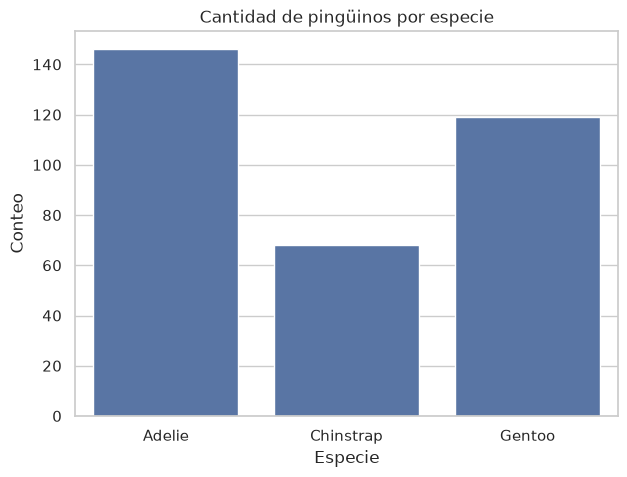

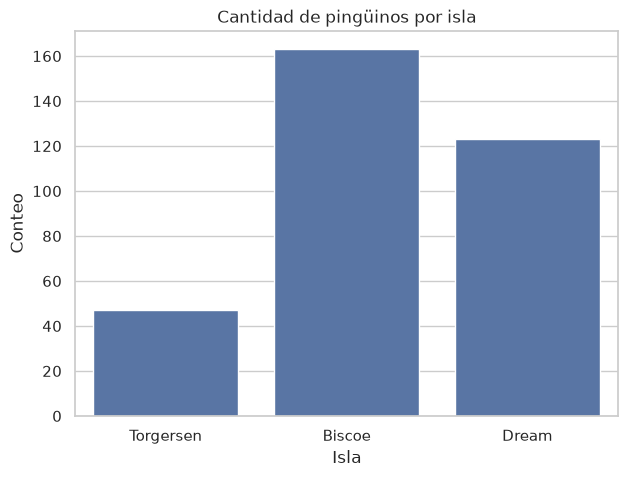

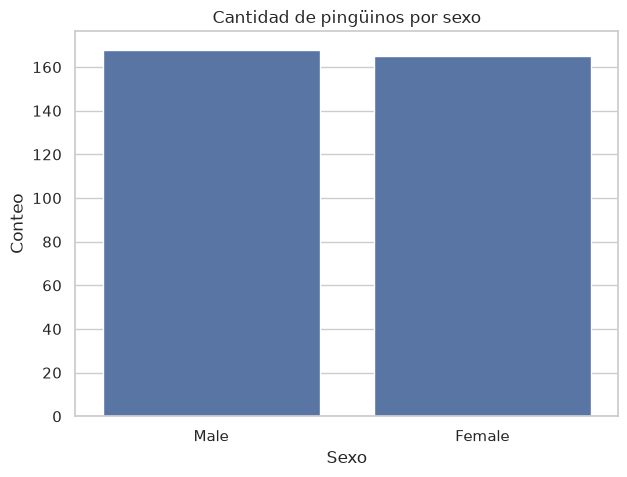

In [12]:
# Configurar el estilo
sns.set_theme(style="whitegrid")

# Gráfico de especies
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df_cleaned,
    x="species",
)
plt.title("Cantidad de pingüinos por especie")
plt.xlabel("Especie")
plt.ylabel("Conteo")
plt.show()

# Gráfico de islas
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df_cleaned,
    x="island"
    
)
plt.title("Cantidad de pingüinos por isla")
plt.xlabel("Isla")
plt.ylabel("Conteo")
plt.show()

# Gráfico de sexo
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df_cleaned,
    x="sex",
)
plt.title("Cantidad de pingüinos por sexo")
plt.xlabel("Sexo")
plt.ylabel("Conteo")
plt.show()


Análisis de los gráficos de conteo

Según los datos analizados, **Torgersen** es la isla con menor presencia de pingüinos, mientras que **Biscoe** concentra la mayor cantidad, seguida por Dream. Esta distribución evidencia una diferencia considerable en la presencia de individuos entre las tres islas.

En relación con las especies, **Adelie** es la dominante, pues presenta el mayor número de individuos. Gentoo ocupa el segundo lugar, mientras que **Chinstrap** registra la menor cantidad. Esta baja representación podría considerarse una señal de posible vulnerabilidad y justificar un estudio más profundo sobre su población y estado de conservación.

Por último, la distribución por sexo es muy equilibrada. La cantidad de machos y hembras es prácticamente la misma, con una diferencia mínima a favor de los machos. Esto indica una proporción cercana al **50 % para cada sexo** dentro de los datos analizados.

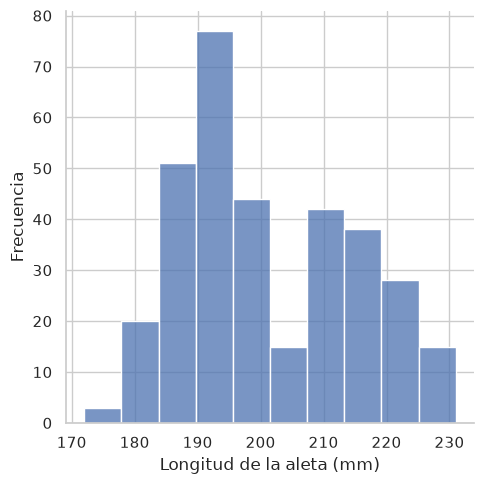

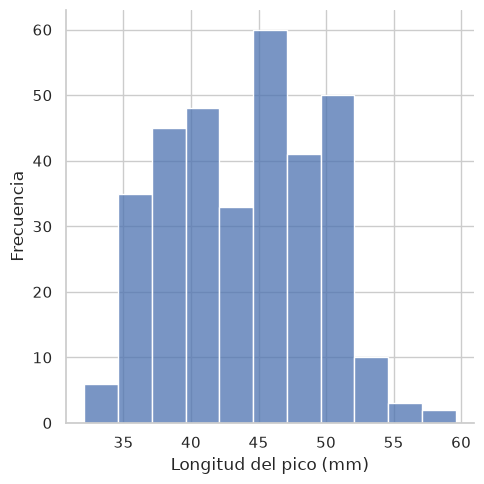

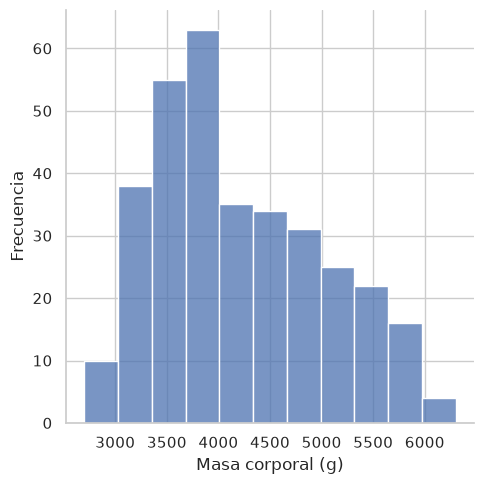

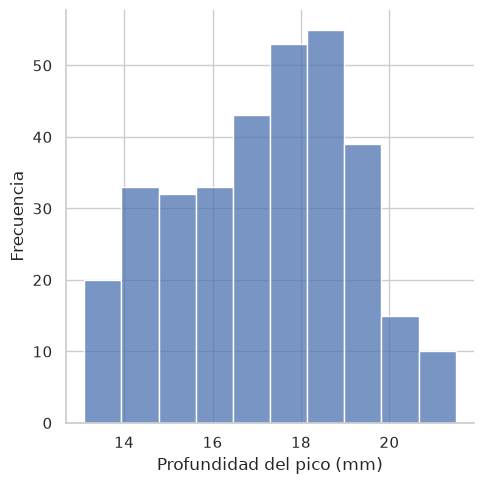

In [13]:
# Longitud de la aleta
sns.displot(
    data=df_cleaned,
    x="flipper_length_mm"
).set_axis_labels(
    "Longitud de la aleta (mm)",
    "Frecuencia"
)

# Longitud del pico
sns.displot(
    data=df_cleaned,
    x="bill_length_mm"
).set_axis_labels(
    "Longitud del pico (mm)",
    "Frecuencia"
)

# Masa corporal
sns.displot(
    data=df_cleaned,
    x="body_mass_g"
).set_axis_labels(
    "Masa corporal (g)",
    "Frecuencia"
)

# Profundidad del pico
sns.displot(
    data=df_cleaned,
    x="bill_depth_mm"
).set_axis_labels(
    "Profundidad del pico (mm)",
    "Frecuencia"
)

Interpretación de los histogramas

A partir de los histogramas, podemos plantear de manera exploratoria que los pingüinos con mayor presencia —y, por tanto, con características que podrían estar asociadas con una mayor capacidad de supervivencia— presentan una **profundidad del pico cercana a 18 o 19 mm**, una **masa corporal comprendida principalmente entre 3.5 y 4.0 kg**, una **longitud del pico entre 40 y 52.5 mm**, con una concentración importante alrededor de los 45 mm, y una **longitud de la aleta cercana a 190 o 195 mm**.

Estos intervalos reúnen las frecuencias más altas de los histogramas, por lo que representan las características morfológicas más comunes entre los pingüinos analizados. En este sentido, puede formularse la hipótesis de que esta combinación de masa corporal, dimensiones del pico y longitud de las aletas constituye un perfil físico frecuente y posiblemente favorable para la adaptación al entorno.

También se observan diferentes concentraciones dentro de algunas distribuciones, especialmente en la longitud de la aleta, la longitud del pico y la masa corporal. Esto sugiere la existencia de varios perfiles corporales, posiblemente asociados con las distintas especies y con las diferencias entre machos y hembras.

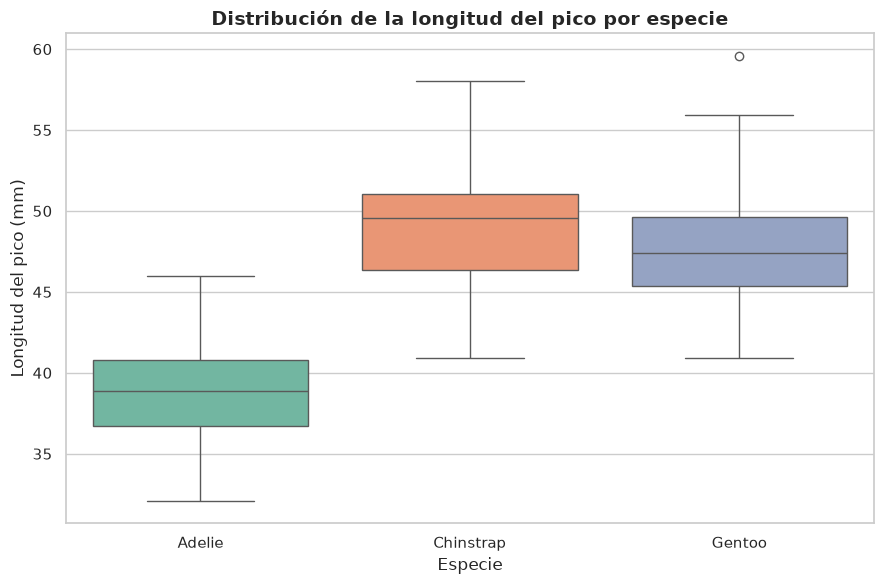

In [14]:
# Crear el gráfico
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_cleaned,
    x="species",
    y="bill_length_mm",
    hue="species",
    legend=False,
    palette="Set2"
)

# Agregar título y nombres de los ejes
plt.title(
    "Distribución de la longitud del pico por especie",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Especie")
plt.ylabel("Longitud del pico (mm)")

# Ajustar y mostrar el gráfico
plt.tight_layout()
plt.show()

Longitud del pico según la especie

La especie **Adelie** presenta la menor longitud promedio del pico, mientras que **Chinstrap** registra la mayor. Por su parte, las longitudes promedio del pico de las especies **Gentoo** y **Chinstrap** son relativamente cercanas.

Esta similitud explica la concentración observada en el histograma general entre los **45 y 50 mm**, intervalo en el que se superpone gran parte de las mediciones correspondientes a estas dos especies.

Además, los diagramas de caja no muestran **valores atípicos**, ya que ninguna observación se encuentra por fuera de los límites establecidos por los bigotes. Esto indica que las longitudes del pico de los individuos se mantienen dentro de los rangos esperados para cada especie.

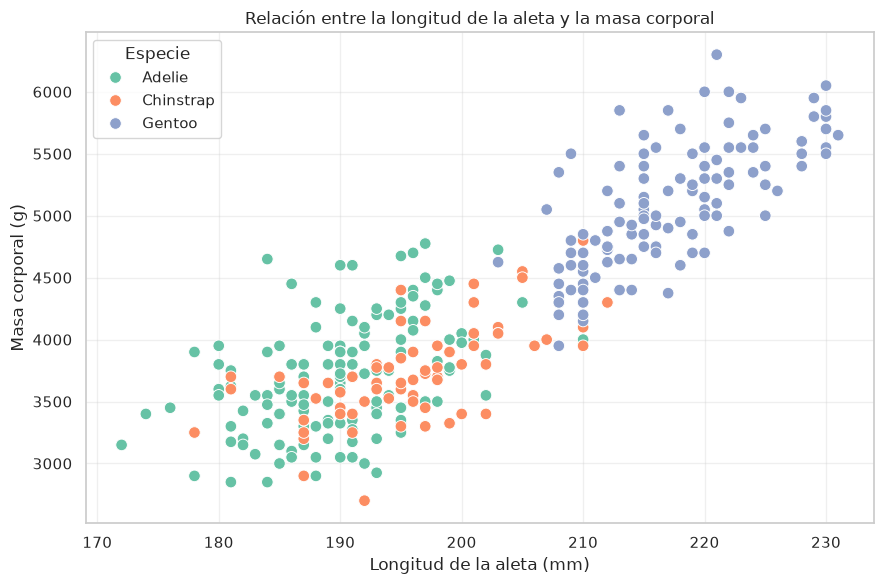

In [15]:

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_cleaned,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",
    palette="Set2",
    s=70
)

plt.title(
    "Relación entre la longitud de la aleta y la masa corporal"
)

plt.xlabel("Longitud de la aleta (mm)")
plt.ylabel("Masa corporal (g)")
plt.legend(title="Especie")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Relación entre la longitud de la aleta y la masa corporal

El gráfico muestra una relación lineal positiva entre la **longitud de la aleta** y la **masa corporal**: a medida que aumenta la longitud de la aleta, también tiende a aumentar la masa del pingüino.

Las especies **Adelie** y **Chinstrap** presentan distribuciones similares y un considerable solapamiento. En cambio, **Gentoo** se concentra en los valores más altos de ambas variables, lo que permite caracterizarla como una especie generalmente más pesada y con aletas más largas que las otras dos.

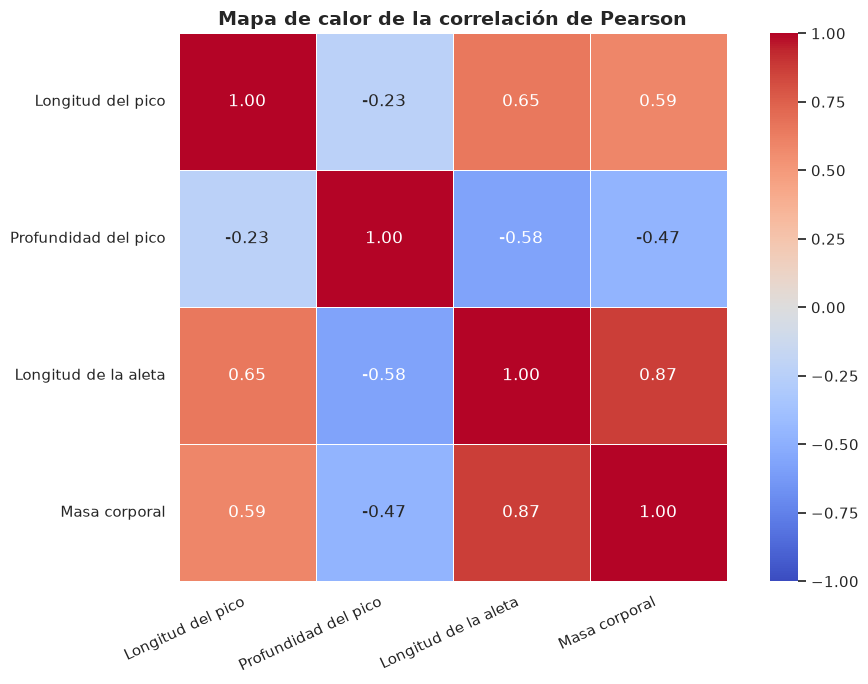

In [16]:
# Calcular la matriz de correlación
matriz_correlacion = columnas_numericas.corr(
    method="pearson"
)

# Traducción de los nombres
nombres_espanol = {
    "bill_length_mm": "Longitud del pico",
    "bill_depth_mm": "Profundidad del pico",
    "flipper_length_mm": "Longitud de la aleta",
    "body_mass_g": "Masa corporal"
}

# Renombrar filas y columnas de la matriz
matriz_correlacion = matriz_correlacion.rename(
    index=nombres_espanol,
    columns=nombres_espanol
)

# Crear el mapa de calor
plt.figure(figsize=(10, 7))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    square=True
)

plt.title(
    "Mapa de calor de la correlación de Pearson",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(rotation=25, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# Parte D
Hipótesis de investigación

1. **Relación entre la masa corporal y la longitud de la aleta:**  
   Existe una relación lineal positiva entre la masa corporal y la longitud de la aleta; es decir, los pingüinos con aletas más largas tienden a presentar una mayor masa corporal.

2. **Diferencias morfológicas entre especies:**  
   Las especies presentan diferencias morfológicas en características como la longitud del pico. Por lo tanto, esta variable puede contribuir a la identificación y clasificación de los pingüinos según su especie.

3. **Relación entre la especie y la isla:**  
   La distribución de los pingüinos entre las islas está relacionada con su especie. Algunas especies se concentran en una sola isla, mientras que otras se encuentran distribuidas en varias. Hay especies endemicas

# Parte E

Evaluación de la primera hipótesis

Como se observa en el mapa de calor, el coeficiente de correlación de Pearson entre la **masa corporal** y la **longitud de la aleta** es de $r = 0.87$. Este valor indica una relación lineal positiva fuerte, por lo que la hipótesis planteada está bien fundamentada y es coherente con los resultados obtenidos.

## Segunda hipótesis: diferencias morfológicas entre especies

- **H₀:** La longitud promedio del pico es igual en las tres especies.
- **H₁:** Al menos una especie presenta una longitud promedio del pico diferente.

In [ ]:
from scipy.stats import f_oneway

# Eliminar registros sin especie o longitud del pico
datos_anova = df_cleaned[
    ["species", "bill_length_mm"]
].dropna()

# Separar la longitud del pico por especie
adelie = datos_anova.loc[
    datos_anova["species"] == "Adelie",
    "bill_length_mm"
]

chinstrap = datos_anova.loc[
    datos_anova["species"] == "Chinstrap",
    "bill_length_mm"
]

gentoo = datos_anova.loc[
    datos_anova["species"] == "Gentoo",
    "bill_length_mm"
]

In [ ]:
medias_por_especie = (
    datos_anova
    .groupby("species")["bill_length_mm"]
    .mean()
)

print("Longitud promedio del pico por especie:")
print(medias_por_especie)

Longitud promedio del pico por especie:
species
Adelie       38.823973
Chinstrap    48.833824
Gentoo       47.568067
Name: bill_length_mm, dtype: float64


In [ ]:
estadistico_f, valor_p = f_oneway(
    adelie,
    chinstrap,
    gentoo
)

print(f"Estadístico F: {estadistico_f:.3f}")
print(f"Valor p: {valor_p:.6e}")

Estadístico F: 397.299
Valor p: 1.380984e-88


Aplicación de ANOVA a las diferencias morfológicas

La prueba ANOVA se utiliza para determinar si la longitud promedio del pico presenta diferencias estadísticamente significativas entre las especies Adelie, Chinstrap y Gentoo.

La hipótesis nula establece que las tres especies tienen la misma longitud promedio del pico:

$$
H_0:\quad
\mu_{\mathrm{Adelie}}
=
\mu_{\mathrm{Chinstrap}}
=
\mu_{\mathrm{Gentoo}}
$$

donde $\mu$ representa la longitud promedio del pico de cada especie. Bajo $H_0$, se supone inicialmente que las diferencias observadas entre las medias se deben únicamente a variaciones aleatorias.

Definición del estadístico F

La idea general del estadístico $F$ consiste en comparar dos estimaciones de variabilidad mediante un cociente. Independientemente de la especie, las longitudes varían de la misma forma en la lista de datos y tienen una distribución constante.

$$
F=
\frac{\text{estimación de varianza 1}}
{\text{estimación de varianza 2}}
$$

El significado específico del numerador y del denominador depende de la prueba estadística en la que se utilice. En el caso de ANOVA, el estadístico $F$ compara la variación entre los grupos con la variación existente dentro de ellos:

$$
F=
\frac{MS_{\text{entre grupos}}}
{MS_{\text{dentro de los grupos}}}
$$

donde $MS$ representa la media cuadrática (*mean square*).

Si $H_0$ fuera verdadera, la variación entre las especies sería semejante a la variación interna y el valor de $F$ estaría generalmente cerca de $1$. En este análisis se obtuvo:

$$
F=397.299
$$

Este resultado indica que la variación entre las especies es considerablemente mayor que la variación dentro de cada especie.

Para determinar si el resultado es estadísticamente significativo, se calcula el valor $p$. El valor $p$ representa la probabilidad de que, suponiendo $H_0$, se obtenga un valor de $F$ igual o mayor que el obtenido.

$$
p=P\left(F\geq397.299\mid H_0\right)
$$

El resultado obtenido fue:

$$
p=1.38\times10^{-88}
$$

Como:

$$
p<0.05
$$

se rechaza $H_0$. Por lo tanto, existen diferencias estadísticamente significativas en la longitud promedio del pico entre las especies. Este resultado respalda la idea de que la longitud del pico puede contribuir a la identificación y clasificación de los pingüinos según su especie.

### Tercera hipótesis: relación entre la especie y la isla

- **H₀:** La especie y la isla son variables independientes; la distribución de las especies no cambia entre las islas.
- **H₁:** La especie y la isla están relacionadas; algunas especies se concentran o presentan una distribución exclusiva en determinadas islas.

In [ ]:
tabla_contingencia = pd.crosstab(
    df_cleaned["species"],
    df_cleaned["island"]
)

Prueba chi-cuadrado de independencia

La prueba chi-cuadrado permite analizar si existe independencia entre dos variables categóricas. En este caso, se utiliza para determinar si la especie del pingüino está relacionada con la isla en la que se encuentra.

El estadístico chi-cuadrado se calcula mediante:

$$
\chi^2=\sum_{i,j}\frac{(O_{ij}-E_{ij})^2}{E_{ij}}
$$

donde:

- $O_{ij}$ representa el número de individuos observado para la combinación de la categoría $i$ y la categoría $j$.
- $E_{ij}$ representa el número de individuos esperado si las variables fueran independientes.

Las frecuencias esperadas se calculan mediante:

$$
E_{ij}=
\frac{
(\text{total de la fila }i)(\text{total de la columna }j)
}{
\text{total general}
}
$$

Un valor pequeño de $\chi^2$ indica que los conteos observados son cercanos a los esperados, lo que es compatible con la independencia entre las variables. En cambio, cuanto mayor es $\chi^2$, mayor es la diferencia entre los datos observados y los esperados bajo el supuesto de independencia. Por lo tanto, un valor elevado de $\chi^2$ proporciona evidencia de una asociación entre la especie y la isla.

In [ ]:
from scipy.stats import chi2_contingency

chi2, valor_p, grados_libertad, frecuencias_esperadas = (
    chi2_contingency(tabla_contingencia)
)

print(f"Estadístico chi-cuadrado: {chi2:.3f}")
print(f"Grados de libertad: {grados_libertad}")
print(f"Valor p: {valor_p:.6e}")

Estadístico chi-cuadrado: 284.590
Grados de libertad: 4
Valor p: 2.281892e-60


Conclusión de la tercera hipótesis

La prueba chi-cuadrado de independencia obtuvo un estadístico de $\chi^2=284.590$, con $4$ grados de libertad y un valor de:

$$
p=2.28\times10^{-60}
$$

Como el valor $p$ es considerablemente menor que el nivel de significancia $\alpha=0.05$, se rechaza la hipótesis nula de independencia. Por lo tanto, existe una asociación estadísticamente significativa entre la **especie** y la **isla** en la que se encuentran los pingüinos.

Este resultado respalda la tercera hipótesis: la distribución de los pingüinos entre las islas depende de su especie. Los pingüinos **Gentoo** se concentran en Biscoe, los **Chinstrap** en Dream y los **Adelie** se distribuyen entre las tres islas. En consecuencia, algunas especies presentan una distribución exclusiva en determinadas islas, mientras que otras poseen una distribución geográfica más amplia dentro de los datos analizados.

# Parte F — Conclusiones y reporte

## A. Hallazgos descriptivos

El análisis descriptivo permitió identificar diferencias importantes en la distribución y en las características morfológicas de los pingüinos.

La especie **Adelie** presentó la mayor cantidad de individuos, seguida por Gentoo y Chinstrap. En cuanto a la distribución geográfica, **Biscoe** fue la isla con mayor número de pingüinos, mientras que **Torgersen** registró la menor cantidad. La distribución por sexo fue equilibrada, con una proporción cercana al 50 % de machos y hembras.

Entre las variables numéricas, la masa corporal presentó una media de aproximadamente **4207 g**, mientras que la longitud promedio de la aleta fue de **200.97 mm**. La correlación de Pearson entre estas dos variables fue de $r=0.873$, lo que indica una relación lineal positiva fuerte: los pingüinos con aletas más largas tienden a presentar una mayor masa corporal.

También se encontraron diferencias en la longitud promedio del pico:

- Adelie: **38.82 mm**.
- Gentoo: **47.57 mm**.
- Chinstrap: **48.83 mm**.

La prueba ANOVA obtuvo $F=397.299$ y $p=1.38\times10^{-88}$. Como $p<0.05$, se concluye que existen diferencias estadísticamente significativas en la longitud promedio del pico entre las especies. Por lo tanto, la medición del pico puede contribuir a diferenciar e identificar las especies.

Por último, la prueba chi-cuadrado obtuvo $\chi^2=284.590$, con $4$ grados de libertad y $p=2.28\times10^{-60}$. Este resultado muestra una asociación estadísticamente significativa entre la especie y la isla. Existe una dependencia entre la isla y la especie estudiada, por lo que conocer la isla también puede contribuir a diferenciar las especies.

## B. Patrones visuales

Los histogramas muestran diferentes concentraciones en las distribuciones de la longitud del pico, la profundidad del pico, la longitud de la aleta y la masa corporal. Estas agrupaciones pueden estar relacionadas con las diferencias morfológicas existentes entre las especies.

Este resultado, junto con la tercera hipótesis, permite plantear que las especies pudieron desarrollar características adaptativas relacionadas con las islas que habitan. Esto se observa especialmente en Chinstrap y Gentoo, que se concentran en una sola isla, mientras que Adelie se encuentra en las tres.

Los diagramas de caja no mostraron valores atípicos en las variables numéricas analizadas. En la longitud de la aleta se observó una mayor concentración de individuos alrededor de los **190–195 mm**, acompañada de una dispersión hacia longitudes superiores.

El gráfico de dispersión confirmó una tendencia positiva entre la longitud de la aleta y la masa corporal. Adelie y Chinstrap presentan un solapamiento considerable, mientras que Gentoo forma un grupo diferenciado en la región de mayor masa corporal y mayor longitud de la aleta.

## C. Próximas hipótesis a probar

A partir de los resultados obtenidos, se proponen las siguientes hipótesis para análisis posteriores:

1. **Diferencias morfológicas según el sexo:**  
   Los machos presentan una masa corporal y dimensiones morfológicas mayores que las hembras.

2. **Efecto conjunto de la especie y el sexo:**  
   La relación entre la longitud de la aleta y la masa corporal cambia según la especie y el sexo del pingüino.

3. **Adaptación de la especie Adelie:**  
   La especie Adelie está presente en las tres islas porque su menor tamaño podría proporcionarle una mayor versatilidad y capacidad de adaptación a distintos ambientes.

4. **Clasificación de especies:**  
   Las mediciones del pico, la longitud de la aleta y la masa corporal permiten clasificar a los pingüinos según su especie.

## Preguntas para un investigador humano

1. ¿Las diferencias observadas entre las islas se deben realmente a la ubicación geográfica o a que cada isla contiene proporciones diferentes de especies?

2. ¿Es necesario controlar la variable `species` al analizar la relación entre la masa corporal y la longitud de la aleta? Es decir, ¿esta relación es independiente de la especie?

3. ¿Los individuos fueron seleccionados de manera aleatoria y mediante el mismo procedimiento de muestreo en las tres islas?

4. ¿La relación entre las características morfológicas cambia cuando se analizan por separado los machos y las hembras?

5. ¿Es posible determinar qué combinación de características morfológicas resulta más favorable para sobrevivir en las tres islas?